In [3]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_package')

Verify a custom environment is compatible

In [4]:
from irc.examples import IdenticalBoxesEnv

env = IdenticalBoxesEnv()
observation, info = env.reset(seed=0)

# state space of the environment
print(f'state_space: {env.state_space}')
# get and set environment parameter
env_param = env.get_param()
print(f'environment parameter: {env_param}')
env.set_param(env_param)
# get and set environment state
state = env.get_state()
print(f'environment state: {state}')
env.set_state(state)

state_space: MultiDiscrete([2 2 3])
environment parameter: [ 0.2   0.05  0.6   0.1  10.   -1.  ]
environment state: (0, 0, 2)


Initialize a manager for rational agents

In [5]:
from irc.manager import AgentManager

defaults = {'env._target_': 'irc.examples.IdenticalBoxesEnv'}
manager = AgentManager(defaults=defaults)

Train and inspect a rational agent

In [6]:
# agent, key = manager.train_agent() # using default environment parameter

env_param = (0.2, 0.05, 0.8, 0.1, 10., -1.)
agent, key = manager.train_agent(env_param=env_param, num_epochs=10)

Checkpoint (epoch 10) loaded.


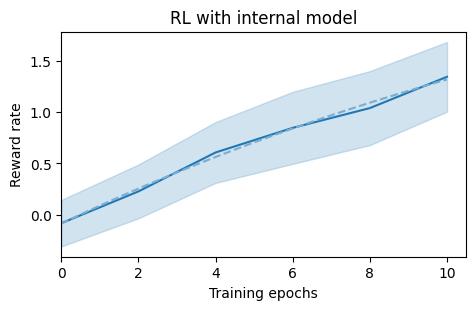

In [7]:
agent, fig = manager.inspect_agent(key)

In [8]:
# if `env` is not specified, agent interacts with its assumed environment
episode = agent.run_one_episode()

# run the agent in an environment different from assumption
env = IdenticalBoxesEnv()
episode = agent.run_one_episode(env=env, max_steps=60)

Sweep over a grid of environment parameters

In [9]:
param_grid = [
    [0.1, 0.2, 0.3],    # p_appear
    [],                 # p_vanish
    [0.6, 0.8],         # p_cue
    [],                 # lambda_center
    [10., 5.],          # r_food
    [],                 # r_move
]
seeds = range(2)
manager.train_agents_on_grid(param_grid=param_grid, seeds=seeds, num_epochs=10)


0 works processed.
All works are processed or being processed.


Monitor the training progress of agents

In [10]:
# Needs change in documentation for below line
# report = manager.overview_agents_on_grid(env_param_grid=env_param_grid, seeds=seeds)
report = manager.overview_agents_on_grid(env_param_grid=param_grid, seeds=seeds)

AttributeError: 'AgentManager' object has no attribute 'overview_agents_on_grid'

Compute likelihood of episode data

In [11]:
# beliefs, logps = agent.compute_likelihoods(observations, actions)
beliefs, logps = agent.compute_likelihoods(episode['observations'], episode['actions'])

Distill a single agent from a family of agents

In [12]:
d_agent, train_stats = manager.distill_agents_on_grid(param_grid, save_path='wukong.pt')

Train Policy Net   100%|##################################################| 60/60 [01:13<00:00,  1.22s/epoch]


Inferring environment parameter with distilled agent (true env param in below example is (0.2, 0.05, 0.6, 0.1, 10., -1.))

In [13]:
d_agent.sga_inference(episode['observations'], episode['actions'], (0.5, 0.1, 0.2, 0.4, 15., -3.))
print(d_agent.model.get_param())

Use default discount parameter gamma=0.99
Use default curiosity parameter ent_coef=0.01
[ 0.30578923  0.00912762  0.5523469   0.134413    8.841353   -1.6812391 ]
